<a href="https://colab.research.google.com/github/ElBaron-27/UACJ_Ruben/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_Ruben_Uribe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Ruben Alejandro Uribe Rodriguez
- **Matrícula:** 271774

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1.1 — Calcula la media, mediana y moda de la columna 'price'.

print('Media:  ', df['price'].mean())
print('Mediana:', df['price'].median())
print('Moda:', df['price'].mode()[0])


Media:   152.7206871868289
Mediana: 106.0
Moda: 100


In [20]:
#Dado que la diferencia entre media y mediana difiere mucho,
#quiero observar cuál es el valor máximo de la columna

df['price'].max()

10000

**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_Esto sugiere que la distribución está sesgada a la derecha ya que el valor máximo es 10,000 lo cual está muy por encima de la mediana es evidente que existen valores extremos que están inflando la media. En otras palabras unos pocos valores muy altos distorsionan el promedio, mientras que la mediana refleja mejor el valor típico de la mayoría de las observaciones.

---
## Actividad 2 — Dispersión (20 pts)

In [21]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.

rango = df['price'].max() - df['price'].min()
varianza = df['price'].var()
desviacion = df['price'].std()
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1


print(f'Rango:               {rango:,.2f}')
print(f'Varianza:            {varianza:,.2f}')
print(f'Desviación estándar: {desviacion:,.2f}')
print(f'Q1 (percentil 25): {Q1:,.2f}')
print(f'Q3 (percentil 75): {Q3:,.2f}')
print(f'IQR:                {IQR:,.2f}')

Rango:               10,000.00
Varianza:            57,674.03
Desviación estándar: 240.15
Q1 (percentil 25): 69.00
Q3 (percentil 75): 175.00
IQR:                106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_El IQR, ya que el rango (10,000) está determinado casi por completo por el valor máximo de la columna, que se considera como un outlier extremo. Esto hace que el rango sea una medida poco confiable de la dispersión típica, ya que un solo dato atípico puede inflarlo completamente. En cambio el IQR (106) no se ve afectado por ese valor extremo y refleja mucho mejor cómo se distribuyen realmente los precios tipicos, mientras que el rango solo nos dice qué tan lejos está el caso más extremo del más bajo.

---
## Actividad 3 — Forma (20 pts)

In [22]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.

print('Asimetría de price:   ', df['price'].skew())
print('Curtosis de price:', df['price'].kurt())

Asimetría de price:    19.118938995046033
Curtosis de price: 585.6728788988286


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta: Los valores de asimetría (19.11) y curtosis (585.67) son extraordinariamente altos, muy por encima de lo que se considera una distribución simétrica o cercana a la normal y sobre todo comparado con los valores de 'Income'. Esto confirma lo que ya hemos estado revisando sobre que en la columna price hay valores extremos como el máximo de 10,000, que distorsionan tanto la forma de la distribución como las medidas de tendencia central y dispersión. Estos valores tan altos anticipan que en la etapa de Datos Atípicos vamos a identificar y probablemente tratar varios outliers extremos en price, dado que la asimetría y curtosis ya señalan su presencia dominante.

---
## Actividad 4 — Visualización (30 pts)

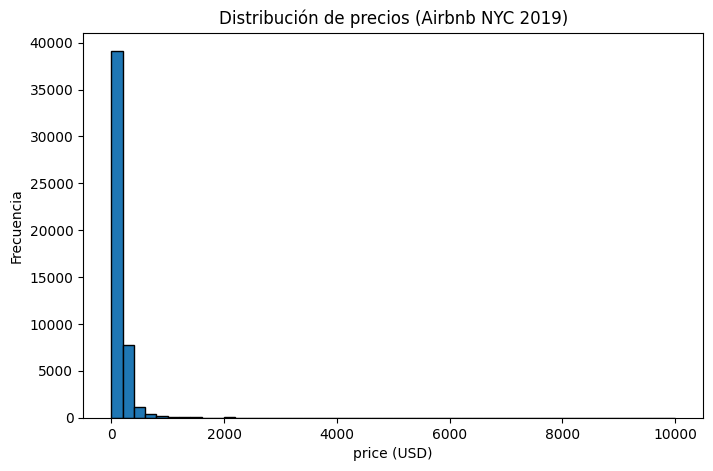

In [23]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.

# Uso 50 bins para tener suficiente detalle sin que las barras sean tan angostas que pierdan lectura
df['price'].plot(kind='hist', bins=50, edgecolor='black', figsize=(8, 5))
plt.title("Distribución de precios (Airbnb NYC 2019)")
plt.xlabel("price (USD)")
plt.ylabel("Frecuencia")
plt.show()


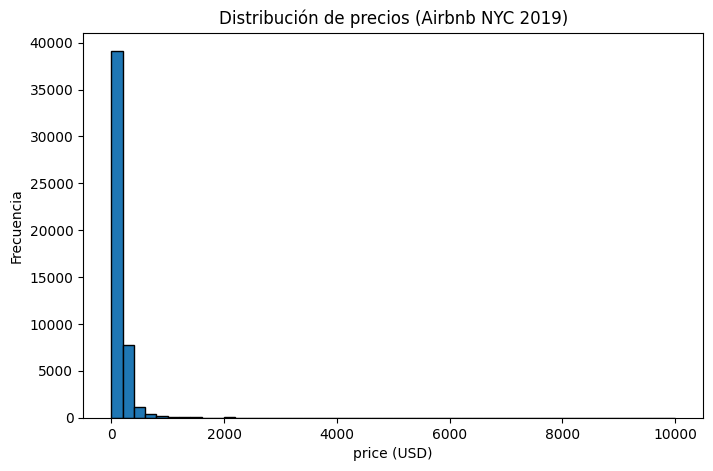

In [24]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.

plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=50, edgecolor='black')
plt.title("Distribución de precios (Airbnb NYC 2019)")
plt.xlabel("price (USD)")
plt.ylabel("Frecuencia")
plt.show()


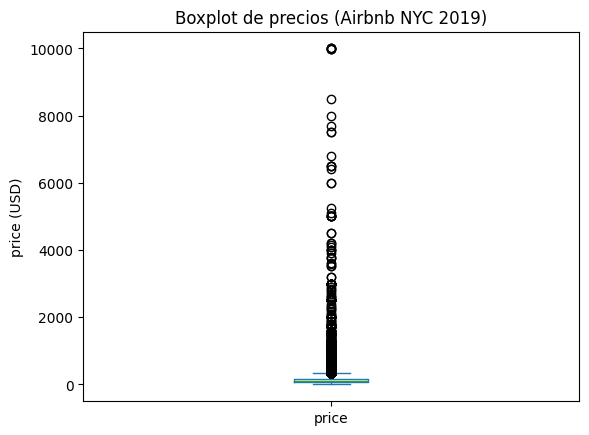

In [25]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).

df['price'].plot(kind='box')
plt.title("Boxplot de precios (Airbnb NYC 2019)")
plt.ylabel("price (USD)")
plt.show()


**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_Desde mi punto de vista es más visible en el bloxplot, ya que se observa que si bien la concentración es un rango limitado, se puede confirmar claramente con existen más outliers que son los que han cambiado y alterado los resultados obtenidos en los puntos anteriores. Esto concuerda con la asimetría de 19.11 y la curtosis de 585.67 calculadas antes, que ya anticipaban colas extremadamente pesadas

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?



Es bastante claro cuando observamos el contexto del dataset que son precios de Airbnb. Si le digo a alguien que el Airbnb promedio en NYC cuesta 152.72 por noche, se le estaría dando una impresión equivocada ya que si bien la mitad de los alojamientos cuestan $106 o menos y el más común de los precios está entre 69 y 175 aun así el promedio de 152.72 está inflado por un puñado de propiedades de lujo que cuestan miles de dólares por noche que no reflejan lo que realmente paga la mayoría de los huéspedes

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |